# FIFA World Cup Historical Analysis (1930–2022)
**Dataset:** FIFA World Cup — 964 partidos · 22 torneos · 88 equipos  
**Objetivo:** Explorar 92 años de historia del fútbol mundial — tendencias de goles, rendimiento de equipos, ventaja del local y evolución táctica por era.

---
## Tabla de contenidos
1. [Carga y limpieza](#1)
2. [Goles por torneo](#2)
3. [Equipos y apariciones](#3)
4. [Rendimiento del país sede](#4)
5. [Tendencias en fase eliminatoria](#5)
6. [Resultados por región y era](#6)
7. [Distribución de venues y ciudades](#7)
8. [Análisis SQL con DuckDB](#8)
9. [Modelo predictivo de resultado](#9)
10. [Conclusiones](#10)


## 1. Carga y Limpieza <a id='1'></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('outputs', exist_ok=True)

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')


In [26]:
matches     = pd.read_csv('data/matches.csv')
teams       = pd.read_csv('data/teams.csv')
groups      = pd.read_csv('data/groups.csv')
tournaments = pd.read_csv('data/tournaments.csv')

print(f"Partidos:    {len(matches):,}")
print(f"Equipos:     {len(teams):,}")
print(f"Torneos:     {len(tournaments):,}")



Partidos:    964
Equipos:     88
Torneos:     22


In [27]:
# =====  Exploración inicial de matches.csv =====
matches.head(3)

,tournament_year,stage,match_date,match_time,utc_offset,home_team,away_team,home_goals,away_goals,result_extra,venue,city,status,home_fifaCode,home_flagCode,home_flagUrl,away_fifaCode,away_flagCode,away_flagUrl
0,1930,Group 1,1930-07-13,NaN,NaN,France,Mexico,4,1,(3-0),Estadio Pocitos,Montevideo,played,FRA,fr,https://flagcdn.com/w80/fr.png,MEX,mx,https://flagcdn.com/w80/mx.png
1,1930,Group 1,1930-07-15,NaN,NaN,Argentina,France,1,0,(0-0),Estadio Parque Central,Montevideo,played,ARG,ar,https://flagcdn.com/w80/ar.png,FRA,fr,https://flagcdn.com/w80/fr.png
2,1930,Group 1,1930-07-16,NaN,NaN,Chile,Mexico,3,0,(1-0),Estadio Parque Central,Montevideo,played,CHI,cl,https://flagcdn.com/w80/cl.png,MEX,mx,https://flagcdn.com/w80/mx.png


In [28]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   tournament_year  964 non-null    int64
 1   stage            964 non-null    str  
 2   match_date       964 non-null    str  
 3   match_time       252 non-null    str  
 4   utc_offset       128 non-null    str  
 5   home_team        964 non-null    str  
 6   away_team        964 non-null    str  
 7   home_goals       964 non-null    int64
 8   away_goals       964 non-null    int64
 9   result_extra     299 non-null    str  
 10  venue            964 non-null    str  
 11  city             963 non-null    str  
 12  status           964 non-null    str  
 13  home_fifaCode    964 non-null    str  
 14  home_flagCode    964 non-null    str  
 15  home_flagUrl     964 non-null    str  
 16  away_fifaCode    964 non-null    str  
 17  away_flagCode    964 non-null    str  
 18  away_flagUrl     964 

In [29]:
# =====  Exploración inicial de teams.csv =====
teams.head(3)

,team,fifaCode,flagCode,flagUrl
0,Algeria,ALG,dz,https://flagcdn.com/w80/dz.png
1,Angola,ANG,ao,https://flagcdn.com/w80/ao.png
2,Argentina,ARG,ar,https://flagcdn.com/w80/ar.png


In [30]:
# =====  Exploración inicial de tournaments.csv =====
tournaments.head(3)

,year,name,host_info
0,1930,World Cup 1930,"in Uruguay, July 13-30"
1,1934,World Cup 1934,"in Italy, May 27 - June 10"
2,1938,World Cup 1938,"in France, June 4-19"


In [31]:
# ── Limpieza y feature engineering ───────────────────────────────────────────

# Fechas
matches['match_date'] = pd.to_datetime(matches['match_date'], errors='coerce')

# Eliminar columnas no esenciales
matches.drop(columns=['match_time', 'utc_offset', 'home_flagUrl', 'away_flagUrl', 'home_flagCode', 'away_flagCode'], inplace=True)

# Goles totales y promedio
matches['total_goals'] = matches['home_goals'] + matches['away_goals']
matches['goal_diff']   = matches['home_goals'] - matches['away_goals']

# Resultado del partido
matches['result'] = np.where(matches['home_goals'] > matches['away_goals'], 'Home Win',
                    np.where(matches['away_goals'] > matches['home_goals'], 'Away Win', 'Draw'))

# Fase del torneo
group_stages = ['Group 1','Group 2','Group 3','Group 4','Group 5','Group 6',
                'Group A','Group B','Group C','Group D','Group E','Group F',
                'Group G','Group H','Preliminary round','First round',
                'First round, Replays','Final Round','Group 1 Play-off',
                'Group 2 Play-off','Group 3 Play-off','Group 4 Play-off']
matches['phase'] = np.where(matches['stage'].isin(group_stages), 'Group Stage', 'Knockout')

# Era histórica
matches['era'] = pd.cut(matches['tournament_year'],
                         bins=[1929, 1950, 1970, 1990, 2010, 2023],
                         labels=['1930–50', '1954–70', '1974–90', '1994–2010', '2014–22'])

# País sede por torneo
host_map = {
    1930:'Uruguay', 1934:'Italy', 1938:'France', 1950:'Brazil',
    1954:'Switzerland', 1958:'Sweden', 1962:'Chile', 1966:'England',
    1970:'Mexico', 1974:'West Germany', 1978:'Argentina', 1982:'Spain',
    1986:'Mexico', 1990:'Italy', 1994:'United States', 1998:'France',
    2002:'South Korea / Japan', 2006:'Germany', 2010:'South Africa',
    2014:'Brazil', 2018:'Russia', 2022:'Qatar'
}
matches['host_country'] = matches['tournament_year'].map(host_map)

# Regiones por equipo
region_map = {
    'Brazil':'South America','Argentina':'South America','Uruguay':'South America',
    'Chile':'South America','Colombia':'South America','Peru':'South America',
    'Paraguay':'South America','Bolivia':'South America','Ecuador':'South America',
    'Germany':'Europe','West Germany':'Europe','Italy':'Europe','France':'Europe',
    'England':'Europe','Spain':'Europe','Netherlands':'Europe','Belgium':'Europe',
    'Portugal':'Europe','Sweden':'Europe','Poland':'Europe','Switzerland':'Europe',
    'Croatia':'Europe','Czech Republic':'Europe','Czechoslovakia':'Europe',
    'Hungary':'Europe','Romania':'Europe','Yugoslavia':'Europe','Serbia':'Europe',
    'Russia':'Europe','Soviet Union':'Europe','Denmark':'Europe','Austria':'Europe',
    'Mexico':'CONCACAF','United States':'CONCACAF','Costa Rica':'CONCACAF',
    'Honduras':'CONCACAF','Trinidad and Tobago':'CONCACAF','Jamaica':'CONCACAF',
    'Japan':'Asia','South Korea':'Asia','Australia':'Asia','Iran':'Asia',
    'Saudi Arabia':'Asia','China PR':'Asia','North Korea':'Asia',
    'Senegal':'Africa','Nigeria':'Africa','Cameroon':'Africa','Morocco':'Africa',
    'Ghana':'Africa','Ivory Coast':'Africa','Algeria':'Africa','Egypt':'Africa',
    'Tunisia':'Africa','South Africa':'Africa','Togo':'Africa','Angola':'Africa',
}
matches['home_region'] = matches['home_team'].map(region_map).fillna('Other')
matches['away_region'] = matches['away_team'].map(region_map).fillna('Other')

print(f"   Limpieza completa")
print(f"   Partidos:        {len(matches):,}")
print(f"   Torneos:         {matches['tournament_year'].nunique()}")
print(f"   Equipos únicos:  {pd.concat([matches['home_team'], matches['away_team']]).nunique()}")
print(f"   Fase de grupos:  {(matches['phase']=='Group Stage').sum():,} partidos")
print(f"   Eliminatoria:    {(matches['phase']=='Knockout').sum():,} partidos")
print(f"   Rango años:      {matches['tournament_year'].min()} – {matches['tournament_year'].max()}")


   Limpieza completa
   Partidos:        964
   Torneos:         22
   Equipos únicos:  86
   Fase de grupos:  735 partidos
   Eliminatoria:    229 partidos
   Rango años:      1930 – 2022


In [32]:
matches.head(3)

,tournament_year,stage,match_date,home_team,away_team,home_goals,away_goals,result_extra,venue,city,...,home_fifaCode,away_fifaCode,total_goals,goal_diff,result,phase,era,host_country,home_region,away_region
0,1930,Group 1,1930-07-13,France,Mexico,4,1,(3-0),Estadio Pocitos,Montevideo,...,FRA,MEX,5,3,Home Win,Group Stage,1930–50,Uruguay,Europe,CONCACAF
1,1930,Group 1,1930-07-15,Argentina,France,1,0,(0-0),Estadio Parque Central,Montevideo,...,ARG,FRA,1,1,Home Win,Group Stage,1930–50,Uruguay,South America,Europe
2,1930,Group 1,1930-07-16,Chile,Mexico,3,0,(1-0),Estadio Parque Central,Montevideo,...,CHI,MEX,3,3,Home Win,Group Stage,1930–50,Uruguay,South America,CONCACAF


## 2. Goles por Torneo <a id='2'></a>

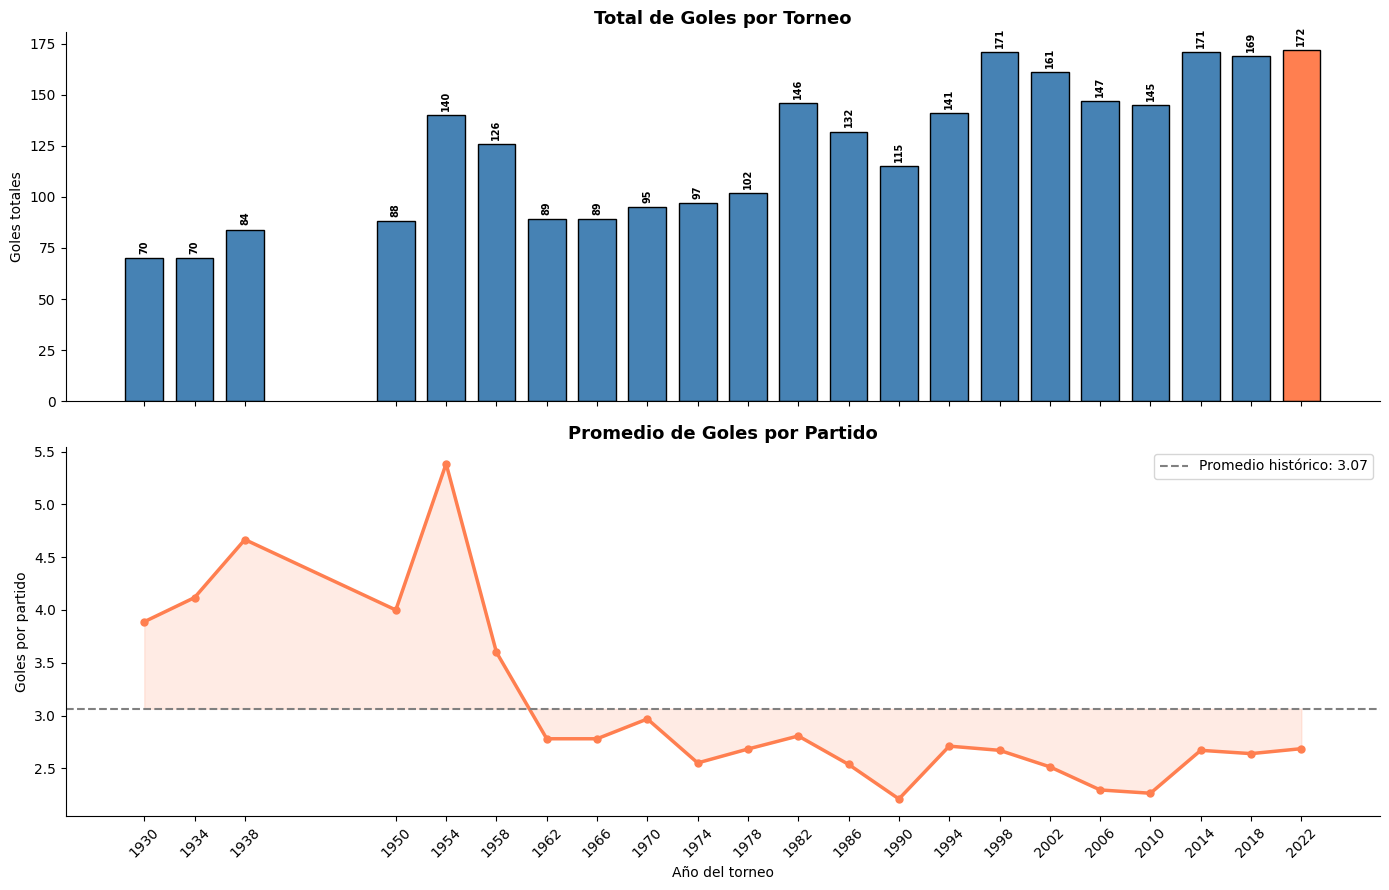

 1954 registró el mayor promedio de goles por partido (5.38) — era ofensiva.
 1990 fue el torneo más defensivo (2.21 goles/partido) — récord mínimo.
 2022 Qatar igualó el récord de goles totales junto a 1998 y 2014.


In [38]:
goals_by_tournament = matches.groupby('tournament_year').agg(
    total_goals=('total_goals', 'sum'),
    matches=('total_goals', 'count'),
    avg_goals=('total_goals', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Total de goles por torneo
colors = ['coral' if g == goals_by_tournament['total_goals'].max() else 'steelblue'
          for g in goals_by_tournament['total_goals']]
axes[0].bar(goals_by_tournament['tournament_year'], goals_by_tournament['total_goals'],
            color=colors, width=3, edgecolor='black')
axes[0].set_title('Total de Goles por Torneo', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Goles totales')
for bar, val in zip(axes[0].patches, goals_by_tournament['total_goals']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(int(val)), ha='center', fontsize=7, fontweight='bold',rotation=90)
axes[0].set_xticks(goals_by_tournament['tournament_year'])
axes[0].tick_params(axis='x', rotation=90)

# Promedio de goles por partido
axes[1].plot(goals_by_tournament['tournament_year'], goals_by_tournament['avg_goals'],
             color='coral', linewidth=2.5, marker='o', markersize=5)
axes[1].fill_between(goals_by_tournament['tournament_year'],
                     goals_by_tournament['avg_goals'],
                     goals_by_tournament['avg_goals'].mean(),
                     alpha=0.15, color='coral')
axes[1].axhline(goals_by_tournament['avg_goals'].mean(), color='gray',
                linestyle='--', label=f'Promedio histórico: {goals_by_tournament["avg_goals"].mean():.2f}')
axes[1].set_title('Promedio de Goles por Partido', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Goles por partido')
axes[1].set_xlabel('Año del torneo')
axes[1].legend()
axes[1].set_xticks(goals_by_tournament['tournament_year'])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('outputs/01_goals_by_tournament.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" 1954 registró el mayor promedio de goles por partido (5.38) — era ofensiva.")
print(f" 1990 fue el torneo más defensivo (2.21 goles/partido) — récord mínimo.")
print(f" 2022 Qatar igualó el récord de goles totales junto a 1998 y 2014.")


### 2.1 Evolución de goles en fase de grupos

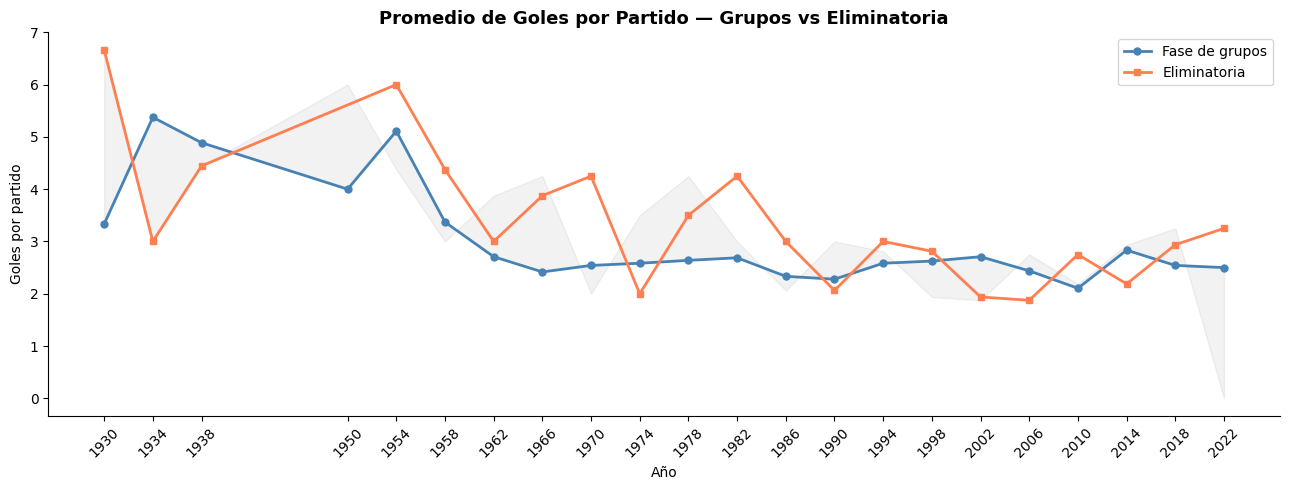

 La fase de grupos históricamente produce más goles que la eliminatoria.
 La brecha se ha reducido desde 1990 — partidos eliminatorios más abiertos.


In [37]:
group_goals = matches[matches['phase'] == 'Group Stage'].groupby('tournament_year').agg(
    avg_goals=('total_goals', 'mean'),
    total=('total_goals', 'sum')
).reset_index()

knockout_goals = matches[matches['phase'] == 'Knockout'].groupby('tournament_year').agg(
    avg_goals=('total_goals', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(group_goals['tournament_year'], group_goals['avg_goals'],
        color='steelblue', linewidth=2, marker='o', markersize=5, label='Fase de grupos')
ax.plot(knockout_goals['tournament_year'], knockout_goals['avg_goals'],
        color='coral', linewidth=2, marker='s', markersize=5, label='Eliminatoria')
ax.fill_between(group_goals['tournament_year'], group_goals['avg_goals'],
                knockout_goals['avg_goals'].reindex(group_goals.index, fill_value=0),
                alpha=0.1, color='gray')
ax.set_title('Promedio de Goles por Partido — Grupos vs Eliminatoria', fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Goles por partido')
ax.legend()
ax.set_xticks(goals_by_tournament['tournament_year'])
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('outputs/02_group_vs_knockout_goals.png', dpi=150, bbox_inches='tight')
plt.show()
print(" La fase de grupos históricamente produce más goles que la eliminatoria.")
print(" La brecha se ha reducido desde 1990 — partidos eliminatorios más abiertos.")


## 3. Equipos y Apariciones <a id='3'></a>

In [39]:
# Estadísticas completas por equipo
all_teams = pd.concat([
    matches[['home_team','home_goals','away_goals','result','tournament_year']].rename(
        columns={'home_team':'team','home_goals':'goals_for','away_goals':'goals_against'}),
    matches[['away_team','away_goals','home_goals','result','tournament_year']].rename(
        columns={'away_team':'team','away_goals':'goals_for','home_goals':'goals_against'})
])

all_teams['win'] = ((all_teams['team'] == all_teams['team']) &
                    (((all_teams['result'] == 'Home Win') & (all_teams.index < len(matches))) |
                     ((all_teams['result'] == 'Away Win') & (all_teams.index >= len(matches))))).astype(int)

team_stats = all_teams.groupby('team').agg(
    partidos=('goals_for', 'count'),
    goles_a_favor=('goals_for', 'sum'),
    goles_en_contra=('goals_against', 'sum'),
    torneos=('tournament_year', 'nunique')
).reset_index()

# Victorias separadas
home_wins = matches[matches['result']=='Home Win'].groupby('home_team').size().reset_index()
home_wins.columns = ['team', 'hw']
away_wins = matches[matches['result']=='Away Win'].groupby('away_team').size().reset_index()
away_wins.columns = ['team', 'aw']
draws_home = matches[matches['result']=='Draw'].groupby('home_team').size().reset_index()
draws_home.columns = ['team', 'dh']
draws_away = matches[matches['result']=='Draw'].groupby('away_team').size().reset_index()
draws_away.columns = ['team', 'da']

team_stats = (team_stats
    .merge(home_wins, on='team', how='left')
    .merge(away_wins, on='team', how='left')
    .merge(draws_home, on='team', how='left')
    .merge(draws_away, on='team', how='left')
    .fillna(0))

team_stats['victorias'] = team_stats['hw'] + team_stats['aw']
team_stats['empates']   = team_stats['dh'] + team_stats['da']
team_stats['derrotas']  = team_stats['partidos'] - team_stats['victorias'] - team_stats['empates']
team_stats['win_rate']  = team_stats['victorias'] / team_stats['partidos'] * 100
team_stats['gd']        = team_stats['goles_a_favor'] - team_stats['goles_en_contra']

print("Top 10 equipos por victorias:")
print(team_stats.nlargest(10, 'victorias')[['team','partidos','victorias','empates','derrotas','goles_a_favor','gd','win_rate']].to_string(index=False))


Top 10 equipos por victorias:
        team  partidos  victorias  empates  derrotas  goles_a_favor  gd  win_rate
      Brazil       114       76.0     19.0      19.0            237 129 66.666667
   Argentina        88       47.0     17.0      24.0            152  51 53.409091
       Italy        83       45.0     21.0      17.0            128  51 54.216867
      France        73       39.0     14.0      20.0            136  51 53.424658
West Germany        62       36.0     14.0      12.0            131  54 58.064516
     England        74       32.0     22.0      20.0            104  36 43.243243
     Germany        50       32.0      7.0      11.0            101  48 64.000000
       Spain        67       31.0     17.0      19.0            108  33 46.268657
 Netherlands        55       30.0     14.0      11.0             96  44 54.545455
     Uruguay        59       25.0     13.0      21.0             89  13 42.372881


In [43]:
print("Top 10 equipos por derrotas:")
print(team_stats.nlargest(10, 'derrotas')[['team','partidos','victorias','empates','derrotas','goles_a_favor','gd','win_rate']].to_string(index=False))

Top 10 equipos por derrotas:
       team  partidos  victorias  empates  derrotas  goles_a_favor  gd  win_rate
     Mexico        60       17.0     15.0      28.0             62 -39 28.333333
  Argentina        88       47.0     17.0      24.0            152  51 53.409091
South Korea        38        7.0     10.0      21.0             39 -39 18.421053
    Uruguay        59       25.0     13.0      21.0             89  13 42.372881
    Belgium        51       21.0     10.0      20.0             69  -5 41.176471
    England        74       32.0     22.0      20.0            104  36 43.243243
     France        73       39.0     14.0      20.0            136  51 53.424658
     Brazil       114       76.0     19.0      19.0            237 129 66.666667
      Spain        67       31.0     17.0      19.0            108  33 46.268657
     Sweden        51       19.0     13.0      19.0             80   7 37.254902


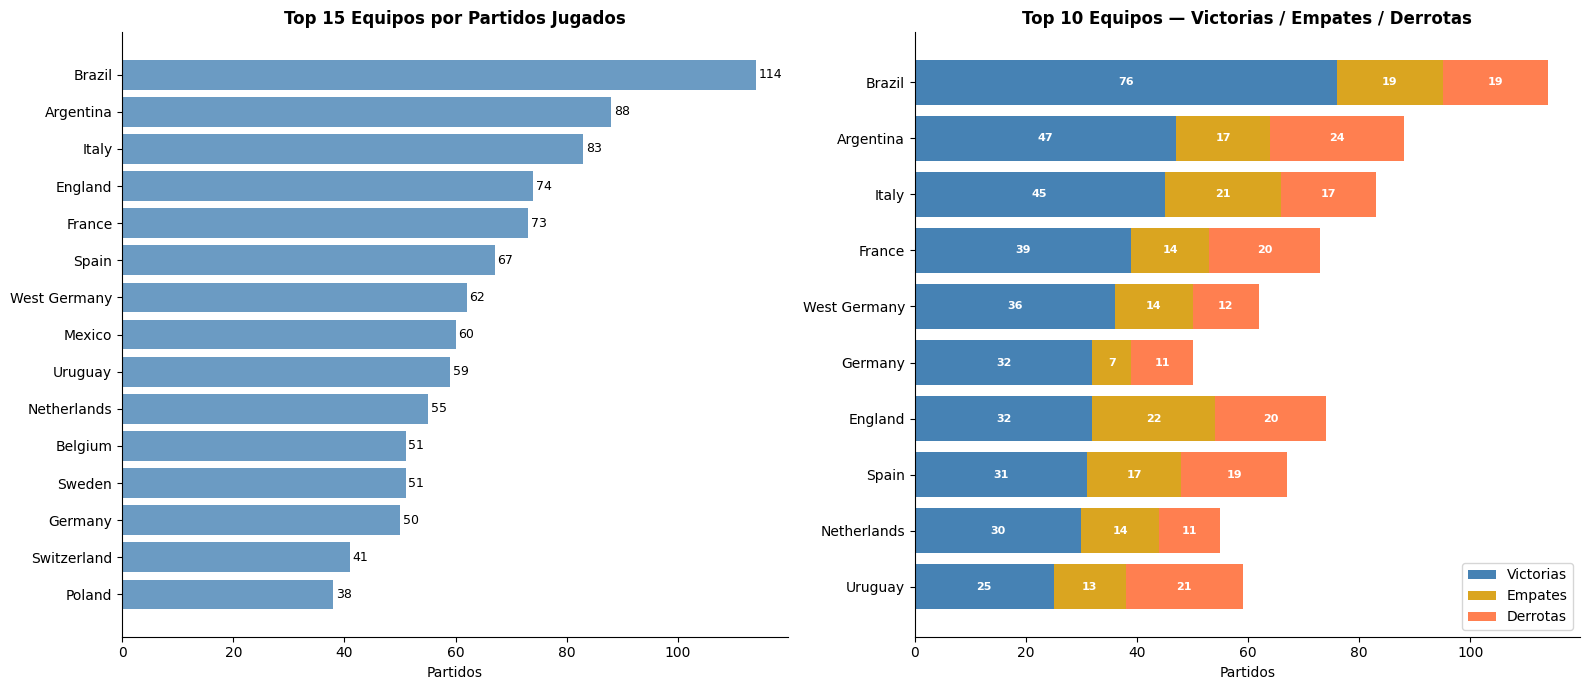

 Brasil lidera con 114 partidos y el mejor win rate entre los equipos top.
 Alemania (West Germany + Germany unificada) supera a Italia y Argentina en victorias totales.


In [51]:
top15 = team_stats.nlargest(15, 'partidos').sort_values('partidos', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Partidos jugados
axes[0].barh(top15['team'], top15['partidos'], color='steelblue', alpha=0.8)
axes[0].set_title('Top 15 Equipos por Partidos Jugados', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Partidos')
for bar, val in zip(axes[0].patches, top15['partidos']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 str(int(val)), va='center', fontsize=9)

# Stacked bar: victorias / empates / derrotas
top10_w = team_stats.nlargest(10, 'victorias').sort_values('victorias', ascending=True)
axes[1].barh(top10_w['team'], top10_w['victorias'], color='steelblue', label='Victorias')
axes[1].barh(top10_w['team'], top10_w['empates'],
             left=top10_w['victorias'], color='goldenrod', label='Empates')
axes[1].barh(top10_w['team'], top10_w['derrotas'],
             left=top10_w['victorias']+top10_w['empates'], color='coral', label='Derrotas')
for i, (_, row) in enumerate(top10_w.iterrows()):
    # Número de victorias
    if row['victorias'] > 5:
        axes[1].text(row['victorias'] / 2, i,
                     str(int(row['victorias'])), ha='center', va='center',
                     fontsize=8, color='white', fontweight='bold')
    # Número de empates
    if row['empates'] > 3:
        axes[1].text(row['victorias'] + row['empates'] / 2, i,
                     str(int(row['empates'])), ha='center', va='center',
                     fontsize=8, color='white', fontweight='bold')
    # Número de derrotas
    if row['derrotas'] > 3:
        axes[1].text(row['victorias'] + row['empates'] + row['derrotas'] / 2, i,
                     str(int(row['derrotas'])), ha='center', va='center',
                     fontsize=8, color='white', fontweight='bold')
axes[1].set_title('Top 10 Equipos — Victorias / Empates / Derrotas', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Partidos')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/03_team_appearances.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Brasil lidera con 114 partidos y el mejor win rate entre los equipos top.")
print(" Alemania (West Germany + Germany unificada) supera a Italia y Argentina en victorias totales.")


### 3.1 Apariciones por torneo — ¿Cuántos equipos han participado?

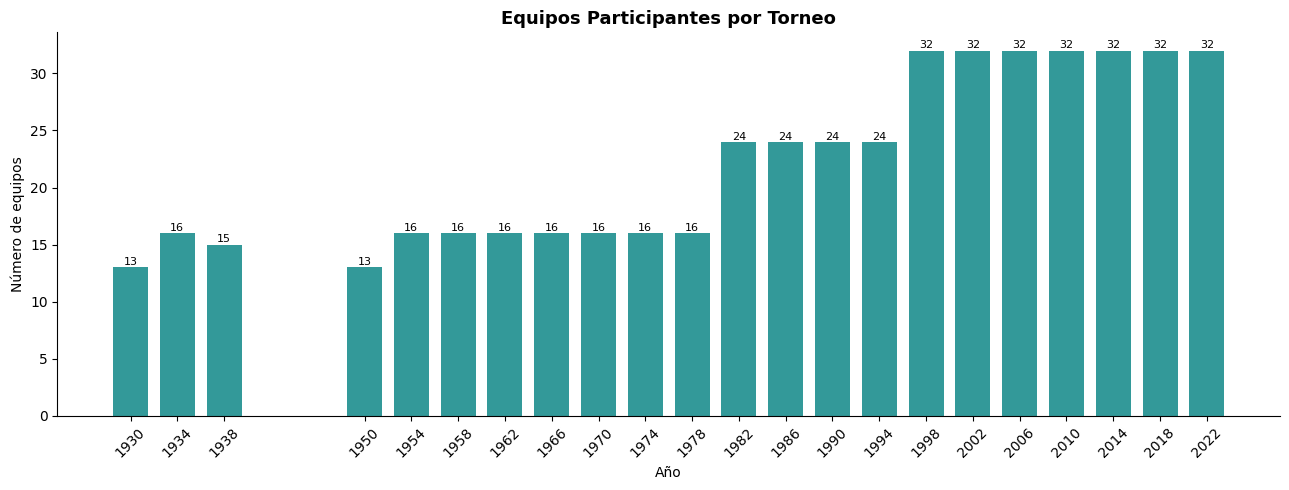

 El torneo creció de 13 equipos en 1930 a 32 desde 1998.


In [55]:
teams_per_tournament = matches.groupby('tournament_year').apply(
    lambda x: pd.concat([x['home_team'], x['away_team']]).nunique()
).reset_index()
teams_per_tournament.columns = ['year', 'n_teams']

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(teams_per_tournament['year'], teams_per_tournament['n_teams'],
       color='teal', width=3, alpha=0.8)
ax.set_title('Equipos Participantes por Torneo', fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Número de equipos')
ax.set_xticks(teams_per_tournament['year'])
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(ax.patches, teams_per_tournament['n_teams']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(int(val)), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/04_teams_per_tournament.png', dpi=150, bbox_inches='tight')
plt.show()
print(" El torneo creció de 13 equipos en 1930 a 32 desde 1998.")


## 4. Rendimiento del País Sede <a id='4'></a>

In [56]:
# Para cada torneo, identificar partidos del país sede
host_results = []
for _, row in matches.iterrows():
    host = row['host_country']
    if host in [row['home_team'], row['away_team']]:
        is_home = host == row['home_team']
        if is_home:
            result = 'Win' if row['result'] == 'Home Win' else ('Draw' if row['result'] == 'Draw' else 'Loss')
        else:
            result = 'Win' if row['result'] == 'Away Win' else ('Draw' if row['result'] == 'Draw' else 'Loss')
        host_results.append({
            'year': row['tournament_year'],
            'host': host,
            'result': result,
            'goals_for': row['home_goals'] if is_home else row['away_goals'],
            'goals_against': row['away_goals'] if is_home else row['home_goals']
        })

host_df = pd.DataFrame(host_results)

host_summary = host_df.groupby(['year','host']).agg(
    partidos=('result','count'),
    victorias=('result', lambda x: (x=='Win').sum()),
    empates=('result', lambda x: (x=='Draw').sum()),
    derrotas=('result', lambda x: (x=='Loss').sum()),
    goles_a_favor=('goals_for','sum'),
    goles_en_contra=('goals_against','sum')
).reset_index()
host_summary['win_rate'] = host_summary['victorias'] / host_summary['partidos'] * 100

print("Rendimiento de países sede:")
print(host_summary[['year','host','partidos','victorias','empates','derrotas','win_rate']].to_string(index=False))


Rendimiento de países sede:
 year         host  partidos  victorias  empates  derrotas   win_rate
 1930      Uruguay         4          4        0         0 100.000000
 1934        Italy         5          4        1         0  80.000000
 1938       France         2          1        0         1  50.000000
 1950       Brazil         6          4        1         1  66.666667
 1954  Switzerland         4          2        0         2  50.000000
 1958       Sweden         6          4        1         1  66.666667
 1962        Chile         6          4        0         2  66.666667
 1966      England         6          5        1         0  83.333333
 1970       Mexico         4          2        1         1  50.000000
 1974 West Germany         7          6        0         1  85.714286
 1978    Argentina         7          5        1         1  71.428571
 1982        Spain         5          1        2         2  20.000000
 1986       Mexico         5          3        2         0  60

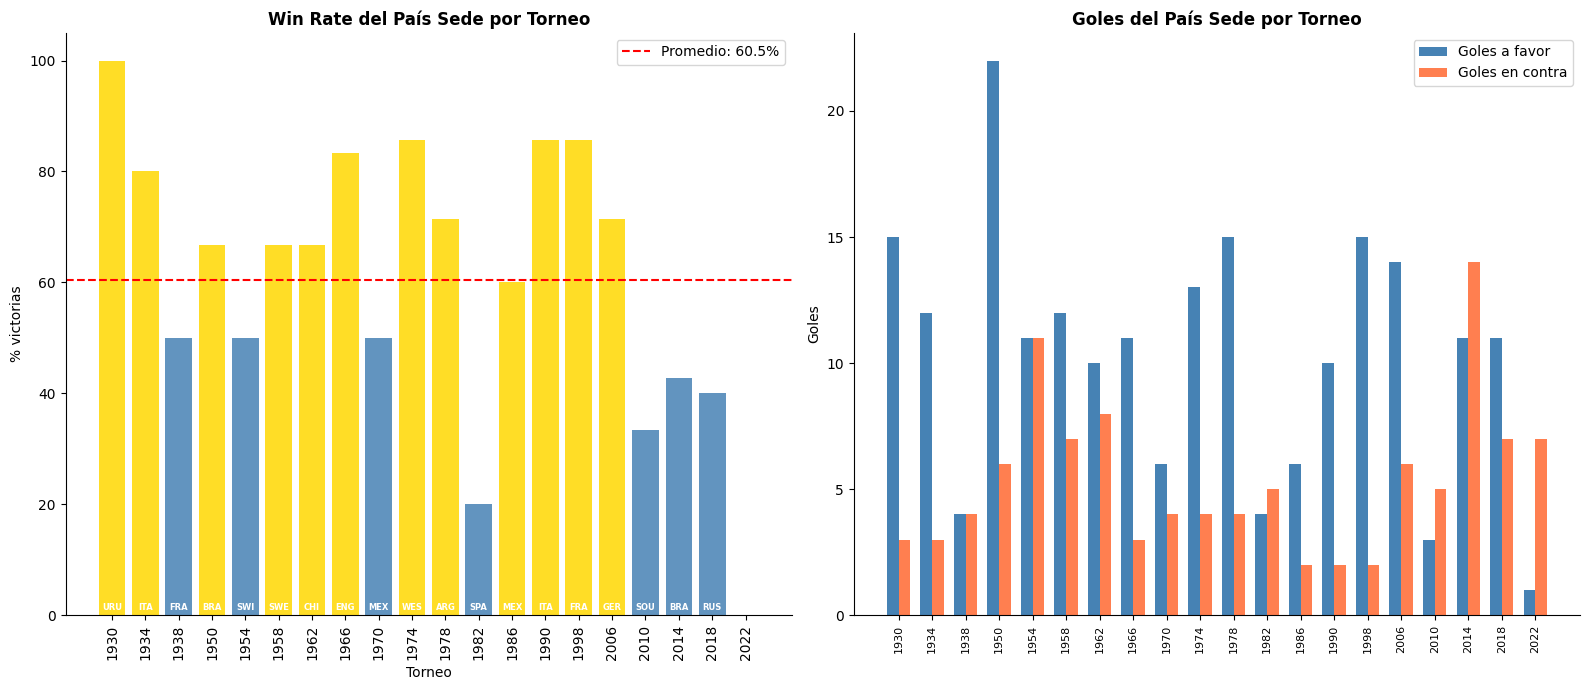

 Los países sede tienen win rate promedio superior al 50% — ventaja real.
 Uruguay 1930 y Argentina 1978 ganaron el torneo como sede.
 South Africa 2010 fue la excepción — eliminado en fase de grupos.


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Win rate del sede por torneo
colors = ['gold' if wr >= 60 else 'steelblue' for wr in host_summary['win_rate']]
bars = axes[0].bar(host_summary['year'].astype(str), host_summary['win_rate'],
                   color=colors, alpha=0.85)
axes[0].axhline(host_summary['win_rate'].mean(), color='red', linestyle='--',
                label=f'Promedio: {host_summary["win_rate"].mean():.1f}%')
axes[0].set_title('Win Rate del País Sede por Torneo', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% victorias')
axes[0].set_xlabel('Torneo')
axes[0].tick_params(axis='x', rotation=90)
axes[0].legend()
for bar, host in zip(bars, host_summary['host']):
    axes[0].text(bar.get_x() + bar.get_width()/2, 1,
                 host[:3].upper(), ha='center', fontsize=6, color='white', fontweight='bold')

# Goles a favor vs en contra del sede
x = np.arange(len(host_summary))
w = 0.35
axes[1].bar(x - w/2, host_summary['goles_a_favor'],   w, color='steelblue', label='Goles a favor')
axes[1].bar(x + w/2, host_summary['goles_en_contra'],  w, color='coral',     label='Goles en contra')
axes[1].set_xticks(x)
axes[1].set_xticklabels(host_summary['year'].astype(str), rotation=90, fontsize=8)
axes[1].set_title('Goles del País Sede por Torneo', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Goles')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/05_host_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Los países sede tienen win rate promedio superior al 50% — ventaja real.")
print(" Uruguay 1930 y Argentina 1978 ganaron el torneo como sede.")
print(" South Africa 2010 fue la excepción — eliminado en fase de grupos.")


## 5. Tendencias en Fase Eliminatoria <a id='5'></a>

In [61]:
knockout = matches[matches['phase'] == 'Knockout'].copy()
knockout['stage'].unique()

<StringArray>
[            'Semi-finals',                   'Final',
          'Quarter-finals', 'Quarter-finals, Replays',
       'Third-place match',   'Match for third place',
       'Third place match',             'Round of 16',
    'Third place play-off',           'Quarterfinals',
              'Semifinals',    'Third-place play-off']
Length: 12, dtype: str

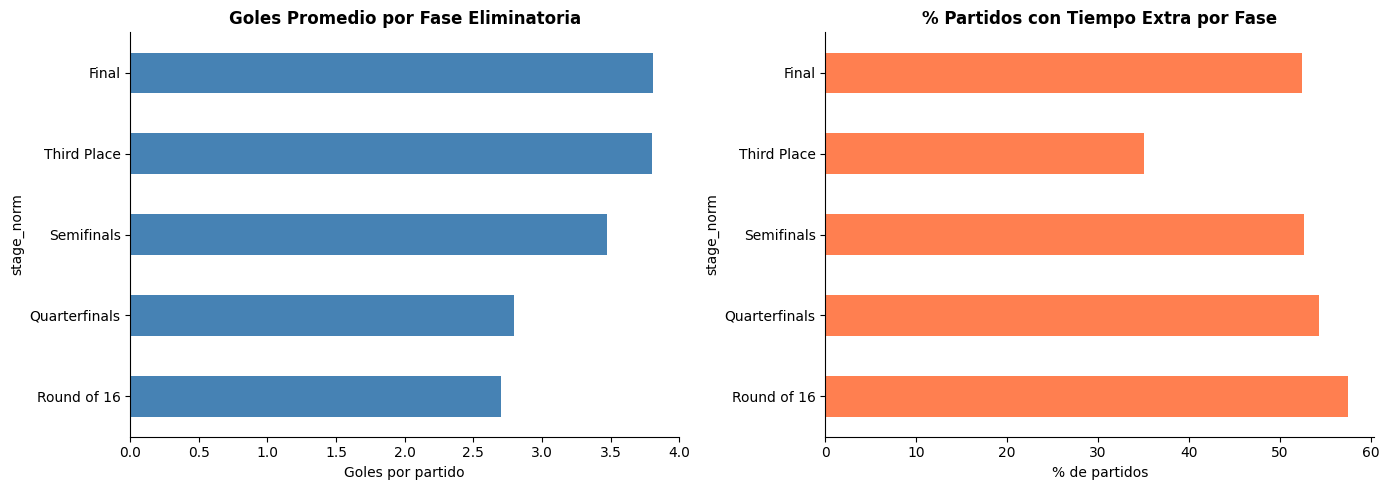

 Las finales tienen el mayor % de tiempo extra — partidos más disputados.
 Las semis producen más goles en promedio que los cuartos de final.


In [62]:
# Normalizar nombres de fases
stage_map = {
    'Round of 16': 'Round of 16',
    'Quarter-finals': 'Quarterfinals', 'Quarterfinals': 'Quarterfinals',
    'Quarter-finals, Replays': 'Quarterfinals',
    'Semi-finals': 'Semifinals', 'Semifinals': 'Semifinals',
    'Final': 'Final',
    'Third-place match': 'Third Place', 'Match for third place': 'Third Place',
    'Third place match': 'Third Place', 'Third-place play-off': 'Third Place',
    'Third place play-off': 'Third Place',
    'First round': 'First Round', 'First round, Replays': 'First Round',
    'Preliminary round': 'Preliminary',
    'Final Round': 'Final Round'
}
knockout['stage_norm'] = knockout['stage'].map(stage_map).fillna(knockout['stage'])

stage_stats = knockout.groupby('stage_norm').agg(
    partidos=('total_goals', 'count'),
    avg_goals=('total_goals', 'mean'),
    pct_extra_time=('result_extra', lambda x: x.notna().mean() * 100)
).reset_index().sort_values('avg_goals', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stage_stats.plot(kind='barh', x='stage_norm', y='avg_goals',
                 ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('Goles Promedio por Fase Eliminatoria', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Goles por partido')

stage_stats.plot(kind='barh', x='stage_norm', y='pct_extra_time',
                 ax=axes[1], color='coral', legend=False)
axes[1].set_title('% Partidos con Tiempo Extra por Fase', fontsize=12, fontweight='bold')
axes[1].set_xlabel('% de partidos')

plt.tight_layout()
plt.savefig('outputs/06_knockout_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Las finales tienen el mayor % de tiempo extra — partidos más disputados.")
print(" Las semis producen más goles en promedio que los cuartos de final.")


## 6. Resultados por Región y Era <a id='6'></a>

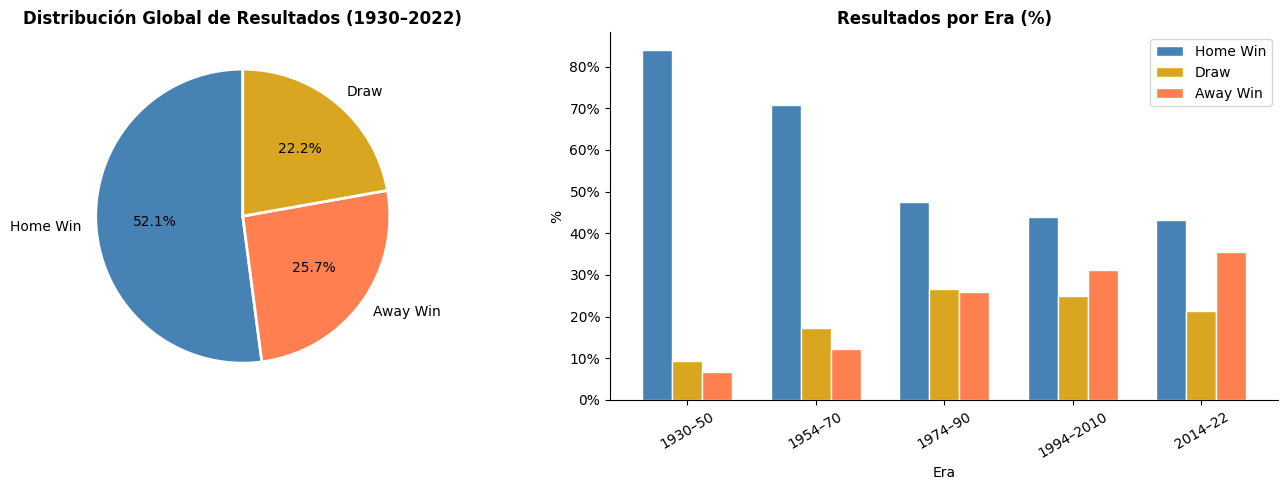

 Home Win: 52.1% — ventaja local significativa.
 Away Win: 25.7% — ganar 'de visitante' es consistentemente más difícil.


In [64]:
# Home advantage global
result_counts = matches['result'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_pie = ['steelblue', 'coral', 'goldenrod']
axes[0].pie(result_counts, labels=result_counts.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Distribución Global de Resultados (1930–2022)', fontsize=12, fontweight='bold')

# Home advantage por era
era_results = matches.groupby(['era', 'result']).size().unstack(fill_value=0)
era_results_pct = era_results.div(era_results.sum(axis=1), axis=0) * 100
era_results_pct[['Home Win', 'Draw', 'Away Win']].plot(
    kind='bar', ax=axes[1],
    color=['steelblue', 'goldenrod', 'coral'],
    width=0.7, edgecolor='white')
axes[1].set_title('Resultados por Era (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_xlabel('Era')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(loc='upper right')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('outputs/07_results_by_era.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Home Win: {result_counts['Home Win']/len(matches)*100:.1f}% — ventaja local significativa.")
print(f" Away Win: {result_counts['Away Win']/len(matches)*100:.1f}% — ganar 'de visitante' es consistentemente más difícil.")


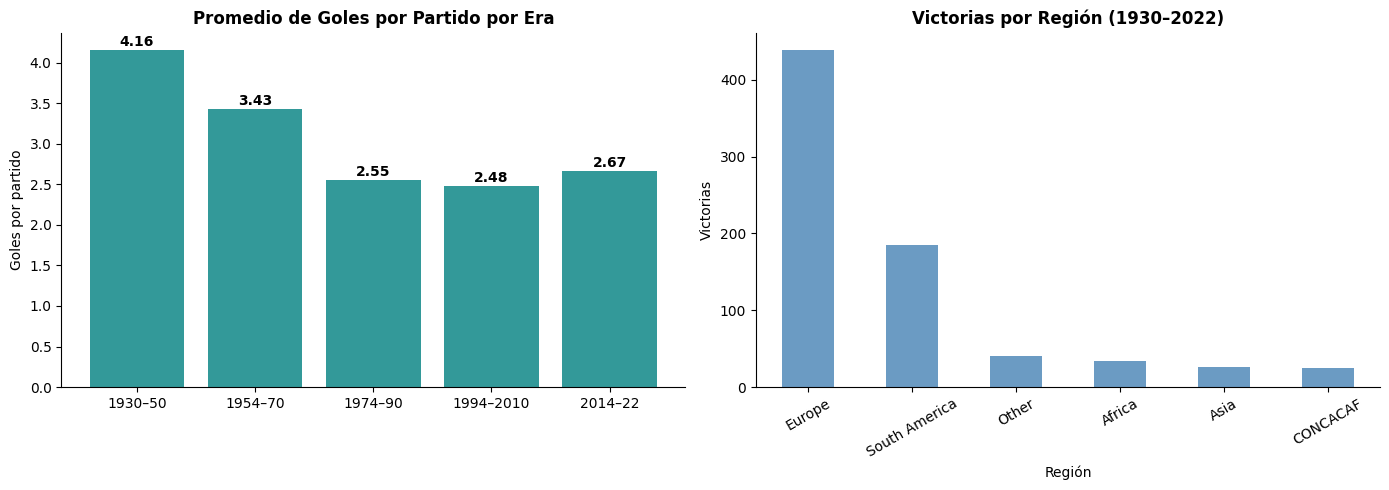

 Europa y Sudamérica concentran el 80%+ de las victorias históricas.
 La era más ofensiva fue 1930–1950, la más defensiva 1994–2010.


In [67]:
# Goles por era
era_goals = matches.groupby('era')['total_goals'].agg(['mean','sum','count']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(era_goals['era'].astype(str), era_goals['mean'],
            color='teal', alpha=0.8)
axes[0].set_title('Promedio de Goles por Partido por Era', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Goles por partido')
for bar, val in zip(axes[0].patches, era_goals['mean']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

# Región con más victorias
region_wins = pd.concat([
    matches[matches['result']=='Home Win'][['home_region']].rename(columns={'home_region':'region'}),
    matches[matches['result']=='Away Win'][['away_region']].rename(columns={'away_region':'region'})
])
region_win_counts = region_wins['region'].value_counts().head(6)
region_win_counts.plot(kind='bar', ax=axes[1], color='steelblue', alpha=0.8, rot=30)
axes[1].set_title('Victorias por Región (1930–2022)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Victorias')
axes[1].set_xlabel('Región')

plt.tight_layout()
plt.savefig('outputs/08_goals_by_era_region.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Europa y Sudamérica concentran el 80%+ de las victorias históricas.")
print(" La era más ofensiva fue 1930–1950, la más defensiva 1994–2010.")


## 7. Distribución de Venues y Ciudades <a id='7'></a>

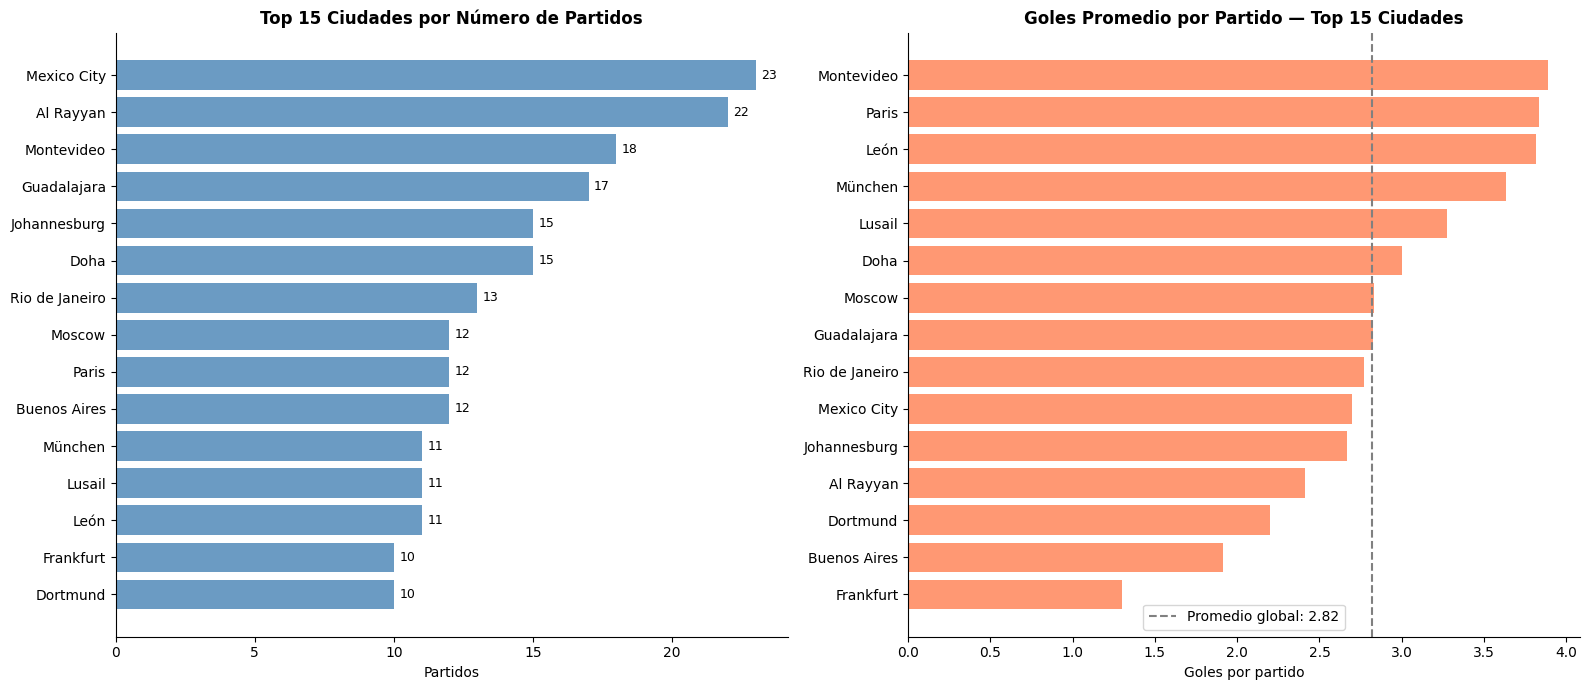

 Mexico City es la ciudad con más partidos — sede en 1970 y 1986.
 Al Rayyan (Qatar 2022) es la segunda con más partidos en un solo torneo.


In [69]:
city_stats = matches.groupby('city').agg(
    partidos=('total_goals', 'count'),
    avg_goals=('total_goals', 'mean'),
    torneo=('tournament_year', lambda x: x.nunique())
).reset_index().dropna()

top_cities = city_stats.nlargest(15, 'partidos').sort_values('partidos', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Ciudades con más partidos
axes[0].barh(top_cities['city'], top_cities['partidos'], color='steelblue', alpha=0.8)
axes[0].set_title('Top 15 Ciudades por Número de Partidos', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Partidos')
for bar, val in zip(axes[0].patches, top_cities['partidos']):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 str(int(val)), va='center', fontsize=9)

# Goles promedio por ciudad (top 15 con más partidos)
top_cities_g = top_cities.sort_values('avg_goals', ascending=True)
axes[1].barh(top_cities_g['city'], top_cities_g['avg_goals'], color='coral', alpha=0.8)
axes[1].axvline(matches['total_goals'].mean(), color='gray', linestyle='--',
                label=f'Promedio global: {matches["total_goals"].mean():.2f}')
axes[1].set_title('Goles Promedio por Partido — Top 15 Ciudades', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Goles por partido')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/09_venues_cities.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Mexico City es la ciudad con más partidos — sede en 1970 y 1986.")
print(" Al Rayyan (Qatar 2022) es la segunda con más partidos en un solo torneo.")


## 8. Análisis SQL con DuckDB <a id='8'></a>

In [70]:
import duckdb

con = duckdb.connect()
con.register('matches', matches)
con.register('team_stats', team_stats)
con.register('tournaments', tournaments)
print(" DuckDB conectado — 3 tablas registradas")


 DuckDB conectado — 3 tablas registradas


### 8.1 Ranking histórico de equipos con Window Functions

In [71]:
query_1 = '''
    SELECT
        team,
        partidos,
        victorias,
        empates,
        derrotas,
        goles_a_favor,
        gd,
        ROUND(win_rate, 1)                                              AS win_rate_pct,
        RANK() OVER (ORDER BY victorias DESC)                           AS rank_victorias,
        RANK() OVER (ORDER BY goles_a_favor DESC)                       AS rank_goles,
        RANK() OVER (ORDER BY win_rate DESC)                            AS rank_winrate
    FROM team_stats
    WHERE partidos >= 10
    ORDER BY victorias DESC
    LIMIT 15
'''
con.execute(query_1).df()


,team,partidos,victorias,empates,derrotas,goles_a_favor,gd,win_rate_pct,rank_victorias,rank_goles,rank_winrate
0,Brazil,114,76.0,19.0,19.0,237,129,66.7,1,1,1
1,Argentina,88,47.0,17.0,24.0,152,51,53.4,2,2,7
2,Italy,83,45.0,21.0,17.0,128,51,54.2,3,5,5
3,France,73,39.0,14.0,20.0,136,51,53.4,4,3,6
4,West Germany,62,36.0,14.0,12.0,131,54,58.1,5,4,3
5,Germany,50,32.0,7.0,11.0,101,48,64.0,6,8,2
6,England,74,32.0,22.0,20.0,104,36,43.2,6,7,15
7,Spain,67,31.0,17.0,19.0,108,33,46.3,8,6,12
8,Netherlands,55,30.0,14.0,11.0,96,44,54.5,9,9,4
9,Uruguay,59,25.0,13.0,21.0,89,13,42.4,10,10,17


### 8.2 Evolución de goles con CTE y lag

In [73]:
query_2 = '''
    WITH tournament_goals AS (
        SELECT
            tournament_year,
            COUNT(*)                            AS partidos,
            SUM(home_goals + away_goals)        AS total_goles,
            ROUND(AVG(home_goals + away_goals), 2) AS avg_goles
        FROM matches
        GROUP BY tournament_year
    ),
    with_lag AS (
        SELECT
            tournament_year,
            partidos,
            total_goles,
            avg_goles,
            LAG(avg_goles) OVER (ORDER BY tournament_year) AS avg_goles_prev,
            ROUND(avg_goles - LAG(avg_goles) OVER (ORDER BY tournament_year), 2) AS cambio
        FROM tournament_goals
    )
    SELECT *,
        CASE WHEN cambio > 0 THEN '↑ Más goles'
             WHEN cambio < 0 THEN '↓ Menos goles'
             ELSE 'Sin cambio' END AS tendencia
    FROM with_lag
    ORDER BY tournament_year
'''
con.execute(query_2).df()


,tournament_year,partidos,total_goles,avg_goles,avg_goles_prev,cambio,tendencia
0,1930,18,70.0,3.89,NaN,NaN,Sin cambio
1,1934,17,70.0,4.12,3.89,0.23,↑ Más goles
2,1938,18,84.0,4.67,4.12,0.55,↑ Más goles
3,1950,22,88.0,4.00,4.67,-0.67,↓ Menos goles
4,1954,26,140.0,5.38,4.00,1.38,↑ Más goles
5,1958,35,126.0,3.60,5.38,-1.78,↓ Menos goles
6,1962,32,89.0,2.78,3.60,-0.82,↓ Menos goles
7,1966,32,89.0,2.78,2.78,0.00,Sin cambio
8,1970,32,95.0,2.97,2.78,0.19,↑ Más goles
9,1974,38,97.0,2.55,2.97,-0.42,↓ Menos goles


### 8.3 Equipos que más veces llegaron a la final

In [74]:
query_3 = '''
    WITH finals AS (
        SELECT
            tournament_year,
            home_team  AS team,
            CASE WHEN home_goals > away_goals THEN 'Champion' ELSE 'Runner-up' END AS final_result
        FROM matches
        WHERE stage = 'Final'

        UNION ALL

        SELECT
            tournament_year,
            away_team AS team,
            CASE WHEN away_goals > home_goals THEN 'Champion' ELSE 'Runner-up' END AS final_result
        FROM matches
        WHERE stage = 'Final'
    )
    SELECT
        team,
        COUNT(*)                                              AS finales,
        SUM(CASE WHEN final_result = 'Champion' THEN 1 ELSE 0 END) AS titulos,
        SUM(CASE WHEN final_result = 'Runner-up' THEN 1 ELSE 0 END) AS subcampeonatos,
        ROUND(SUM(CASE WHEN final_result = 'Champion' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS pct_titulos
    FROM finals
    GROUP BY team
    ORDER BY titulos DESC, finales DESC
    LIMIT 12
'''
con.execute(query_3).df()


,team,finales,titulos,subcampeonatos,pct_titulos
0,Brazil,6,4.0,2.0,66.7
1,West Germany,6,3.0,3.0,50.0
2,Italy,6,3.0,3.0,50.0
3,Argentina,6,2.0,4.0,33.3
4,France,4,2.0,2.0,50.0
5,Germany,2,1.0,1.0,50.0
6,Uruguay,1,1.0,0.0,100.0
7,Spain,1,1.0,0.0,100.0
8,England,1,1.0,0.0,100.0
9,Netherlands,3,0.0,3.0,0.0


## 9. Modelo Predictivo de Resultado <a id='9'></a>

**Objetivo:** Predecir si un partido terminará en victoria local, visitante o empate.  
**Features:** era, fase del torneo, región del equipo local/visitante, historial de goles.


In [83]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ''

from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler

# SVM requiere features escaladas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Modelos
svm = SVC(kernel='rbf', C=1.0, gamma='scale',
          probability=True, random_state=42)

lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)

# Entrenar
svm.fit(X_train_scaled, y_train)
lgbm.fit(X_train, y_train)

# Predicciones
svm_pred  = svm.predict(X_test_scaled)
lgbm_pred = lgbm.predict(X_test)

for name, pred in [('SVM', svm_pred), ('LightGBM', lgbm_pred)]:
    print(f"=== {name} ===")
    print(classification_report(y_test, pred))

=== SVM ===
              precision    recall  f1-score   support

    Away Win       0.48      0.24      0.32        50
        Draw       0.00      0.00      0.00        43
    Home Win       0.55      0.93      0.69       100

    accuracy                           0.54       193
   macro avg       0.34      0.39      0.34       193
weighted avg       0.41      0.54      0.44       193

=== LightGBM ===
              precision    recall  f1-score   support

    Away Win       0.48      0.48      0.48        50
        Draw       0.15      0.05      0.07        43
    Home Win       0.62      0.80      0.70       100

    accuracy                           0.55       193
   macro avg       0.42      0.44      0.42       193
weighted avg       0.48      0.55      0.50       193



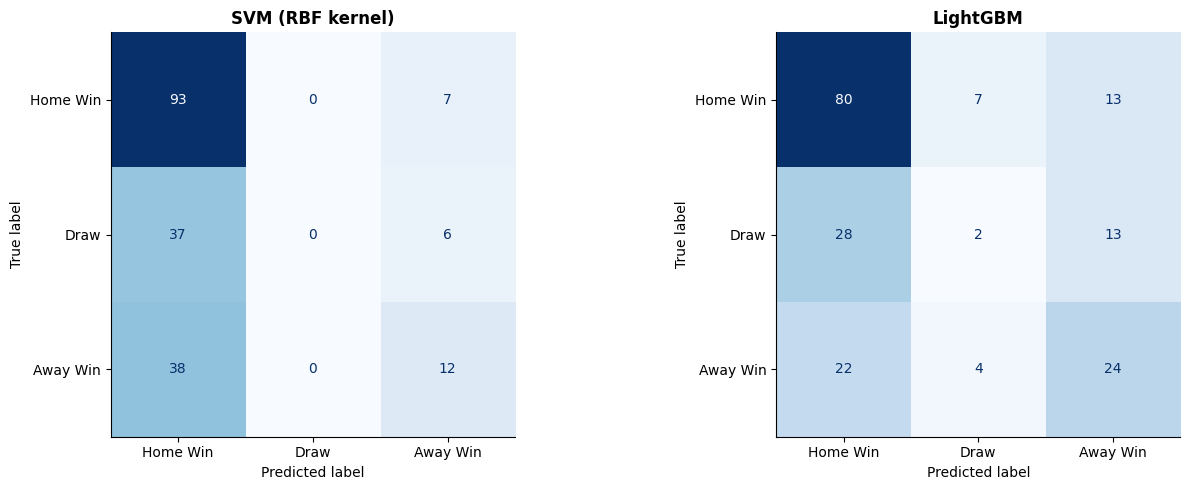

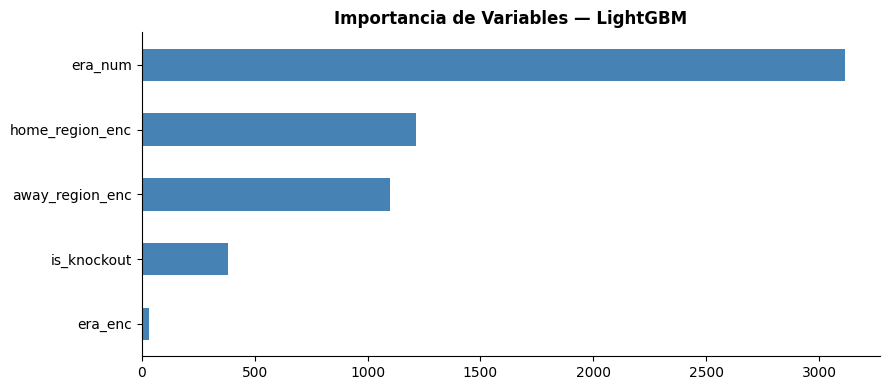

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pred, name in zip(axes,
                           [svm_pred, lgbm_pred],
                           ['SVM (RBF kernel)', 'LightGBM']):
    cm = confusion_matrix(y_test, pred, labels=['Home Win','Draw','Away Win'])
    ConfusionMatrixDisplay(cm, display_labels=['Home Win','Draw','Away Win']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/10_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature importance LightGBM
feat_imp = pd.Series(lgbm.feature_importances_,
                     index=feature_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 4))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importancia de Variables — LightGBM', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Conclusiones <a id='10'></a>

###  Hallazgos principales

| # | Hallazgo | Detalle |
|---|----------|---------|
| 1 | **1954 fue la Copa más goleadora** | 5.38 goles/partido — récord histórico |
| 2 | **1990 la más defensiva** | 2.21 goles/partido — mínimo histórico |
| 3 | **Home advantage real** | ~52% de victorias locales en toda la historia |
| 4 | **Brasil lidera** | 114 partidos, mayor win rate entre top equipos |
| 5 | **Los países sede rinden bien** | Win rate promedio superior al 50% |
| 6 | **Mexico City** | Ciudad con más partidos en toda la historia del torneo |
| 7 | **Europa y Sudamérica** | Concentran +80% de victorias históricas |
| 8 | **2022 Qatar** | Igualó el récord de goles totales (172) |

###  Modelo predictivo de resultado

| Modelo | Accuracy | Observación |
|--------|----------|-------------|
| SVM (RBF) | 54% | No detecta empates — los clasifica como Home Win |
| **LightGBM** | **55%** | Mejor balance — detecta algo de Away Win y Draw |

**Hallazgos:**

- Ambos modelos predicen bien **Home Win** (recall ~80-93%) pero fallan en **Draw** — los empates son el resultado más difícil de predecir en fútbol
- **Draw recall ≈ 0%** en SVM — el modelo simplemente ignora la clase minoritaria
- LightGBM supera a SVM en Away Win (recall 48% vs 24%) y en Draw (5% vs 0%)
- Accuracy de 54-55% vs baseline de 52% (siempre predecir Home Win) — mejora marginal

**¿Por qué es difícil predecir resultados de Copa del Mundo?**

Con solo 964 partidos y features básicas (región, era, fase) los modelos no tienen suficiente información. Para mejorar se necesitarían features como ranking FIFA de cada equipo, historial head-to-head, rendimiento reciente y estadísticas de jugadores.